In [26]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [27]:
df = pd.read_csv("bitcoin_dataset_actualizado.csv")

# si tu csv no tiene headers usa esto:
# df = pd.read_csv("bitcoin_dataset_actualizado.csv",
#                  header=None,
#                  names=["date","open","high","low","close","volume"])

df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values("timestamp")
df = df.reset_index(drop=True)

print(df.tail())

      timestamp      open      high       low     close       volume
3118 2026-03-01  66973.26  68199.99  65056.00  65776.47  23201.85859
3119 2026-03-02  65776.48  70096.00  65259.21  68830.06  32010.38431
3120 2026-03-03  68830.06  69258.08  66158.00  68338.00  24972.24180
3121 2026-03-04  68338.01  74050.00  67400.00  72666.77  44919.07610
3122 2026-03-05  72666.77  73306.82  72336.76  72787.49   3916.61607


In [28]:
df["target"] = df["open"].shift(-1)

df = df.dropna()


In [29]:
features = ["open","high","low","close","volume"]

X = df[features].values
y = df["target"].values.reshape(-1,1)

In [30]:
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

In [31]:
LOOKBACK = 60

X_seq = []
y_seq = []

for i in range(LOOKBACK, len(X_scaled)):

    X_seq.append(X_scaled[i-LOOKBACK:i])

    y_seq.append(y_scaled[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("Shape X:", X_seq.shape)
print("Shape y:", y_seq.shape)

Shape X: (3062, 60, 5)
Shape y: (3062, 1)


In [32]:
split = int(len(X_seq) * 0.8)

X_train = X_seq[:split]
X_test  = X_seq[split:]

y_train = y_seq[:split]
y_test  = y_seq[split:]


In [33]:

model = Sequential()

model.add(LSTM(64, input_shape=(LOOKBACK, len(features))))
model.add(Dropout(0.2))

model.add(Dense(32, activation="relu"))
model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,033 (78.25 KB)

 Trainable params: 20,033 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
history = model.fit(

    X_train,
    y_train,

    epochs=100,
    batch_size=8,

    validation_data=(X_test, y_test),

    verbose=1
)

Epoch 1/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0022 - val_loss: 0.0050
Epoch 2/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 5.2698e-04 - val_loss: 6.5428e-04
Epoch 3/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 4.9395e-04 - val_loss: 7.0719e-04
Epoch 4/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 4.2276e-04 - val_loss: 0.0027
Epoch 5/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 4.0124e-04 - val_loss: 0.0015
Epoch 6/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 2.7610e-04 - val_loss: 5.0875e-04
Epoch 7/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 3.1481e-04 - val_loss: 0.0010
Epoch 8/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 2.7619e-04 - val_loss: 0.0033
Epoch 9/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 3.2453e-04 - val_loss: 0.0026
Epoch 10/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 2.6866e-04 - val_loss: 0.0057
Epoch 11/100
307/307 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 2.4238e-

In [35]:
pred_scaled = model.predict(X_test)

pred = scaler_y.inverse_transform(pred_scaled)
real = scaler_y.inverse_transform(y_test)


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [36]:
mae = mean_absolute_error(real, pred)
rmse = np.sqrt(mean_squared_error(real, pred))

print("\nMÉTRICAS")

print("MAE:", mae)
print("RMSE:", rmse)



MÉTRICAS
MAE: 7001.485547512235
RMSE: 8075.985072610941


In [37]:
last_window = X_scaled[-LOOKBACK:]

last_window = last_window.reshape(1, LOOKBACK, len(features))

pred_next_scaled = model.predict(last_window)

pred_next = scaler_y.inverse_transform(pred_next_scaled)

print("\nPredicción Open mañana:")

print(pred_next[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Predicción Open mañana:
68871.984


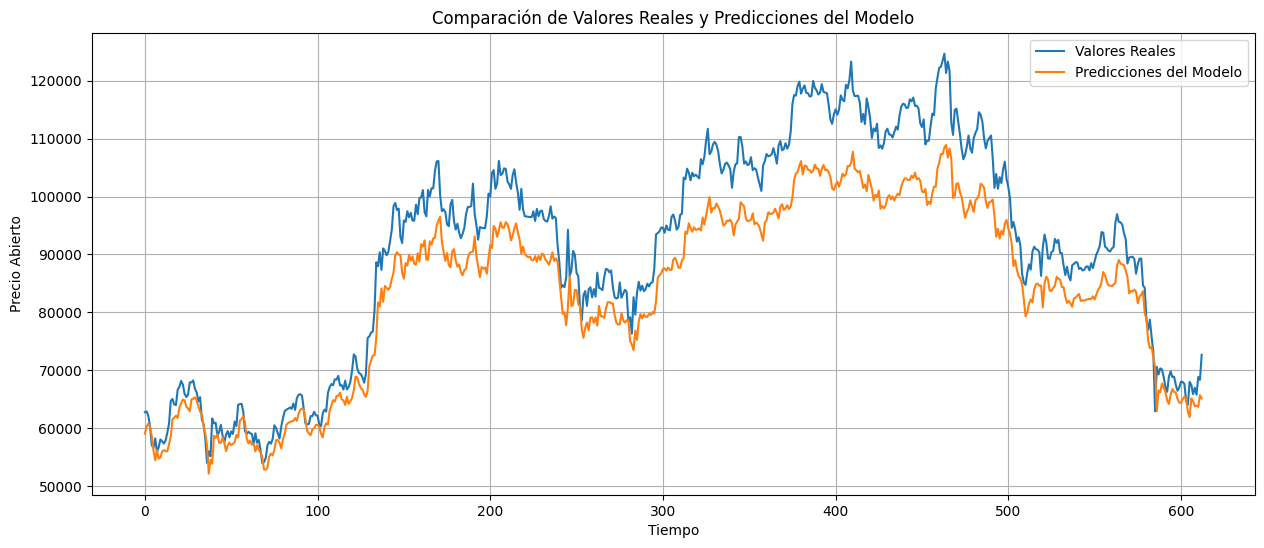

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.plot(real, label="Valores Reales")
plt.plot(pred, label="Predicciones del Modelo")
plt.title("Comparación de Valores Reales y Predicciones del Modelo")
plt.xlabel("Tiempo")
plt.ylabel("Precio Abierto")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
model.save('bitcoin_price_predictor.h5')
print("Modelo guardado como 'bitcoin_price_predictor.h5'")

Modelo guardado como 'bitcoin_price_predictor.h5'
